In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/av_train_data_synthetic_dates.csv")
print("Shape:", df.shape)
df.head()


Shape: (318438, 22)


,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,...,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay,synthetic_admission_datetime,synthetic_discharge_datetime,days_to_next_admission,readmitted_30_days
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,...,Emergency,Extreme,2,51-60,4911.0,0-10,2018-01-13 18:44:09,2018-01-20 07:58:57,24.005949,1
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,...,Trauma,Extreme,2,51-60,5954.0,41-50,2018-02-13 08:07:31,2018-04-04 18:32:04,64.495069,0
2,3,10,e,1,X,2,anesthesia,S,E,2.0,...,Trauma,Extreme,2,51-60,4745.0,31-40,2018-06-08 06:24:58,2018-07-17 16:26:42,83.652674,0
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,...,Trauma,Extreme,2,51-60,7272.0,41-50,2018-10-09 08:06:33,2018-11-27 16:57:23,9.080961,1
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,...,Trauma,Extreme,2,51-60,5558.0,41-50,2018-12-06 18:53:58,2019-01-24 10:34:56,41.334329,0


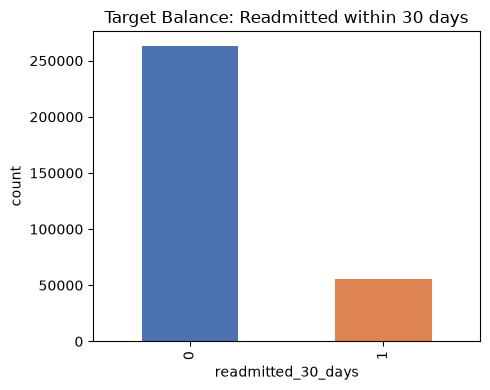

readmitted_30_days
0    0.8259
1    0.1741
Name: proportion, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
df["readmitted_30_days"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Target Balance: Readmitted within 30 days")
ax.set_xlabel("readmitted_30_days")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig("eda2_target_balance.png", dpi=100)
plt.show()

print(df["readmitted_30_days"].value_counts(normalize=True).round(4))


In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column:")
print(missing)
print(f"\nAs % of total rows:\n{(missing / len(df) * 100).round(2)}")
# Note: days_to_next_admission is missing for patients with only 1
# encounter — expected, not a data quality issue.


Missing values per column:
Bed Grade                   113
City_Code_Patient          4532
days_to_next_admission    92017
dtype: int64

As % of total rows:
Bed Grade                  0.04
City_Code_Patient          1.42
days_to_next_admission    28.90
dtype: float64


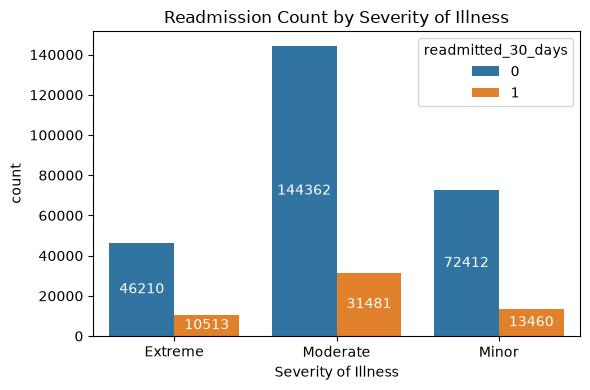

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Severity of Illness",
    hue="readmitted_30_days",
    ax=ax
)

ax.bar_label(ax.containers[0], label_type="center", color="white")
ax.bar_label(ax.containers[1], label_type="center", color="white")

ax.set_title("Readmission Count by Severity of Illness")

plt.tight_layout()
plt.savefig("eda2_severity.png", dpi=100)
plt.show()

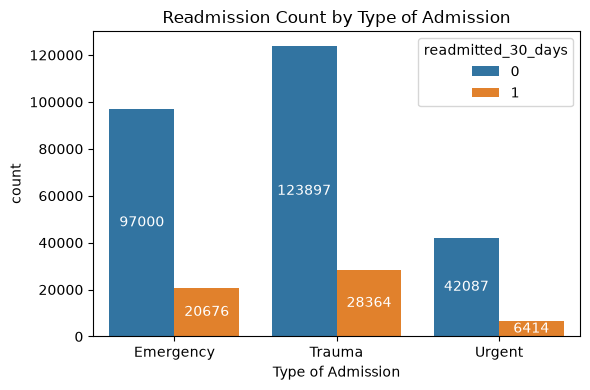

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Type of Admission", hue="readmitted_30_days", ax=ax)
ax.bar_label(ax.containers[0], label_type="center", color="white")
ax.bar_label(ax.containers[1], label_type="center", color="white")
ax.set_title("Readmission Count by Type of Admission")
plt.tight_layout()
plt.savefig("eda2_admission_type.png", dpi=100)
plt.show()

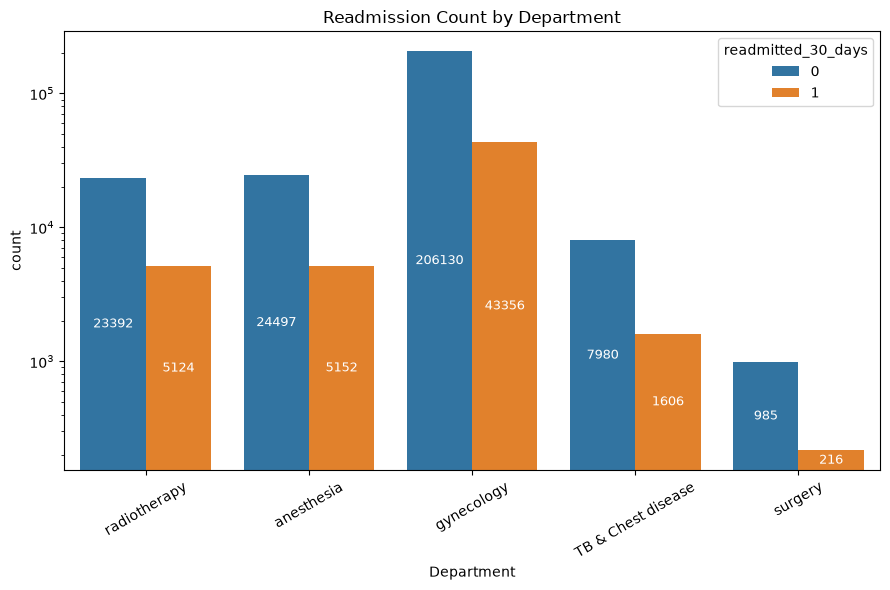

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.countplot(data=df, x="Department", hue="readmitted_30_days", ax=ax)

ax.bar_label(ax.containers[0], label_type="center", color="white", fontsize=9)
ax.bar_label(ax.containers[1], label_type="center", color="white", fontsize=9)

ax.set_yscale("log") 
ax.set_title("Readmission Count by Department")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("eda2_department.png", dpi=100)
plt.show()

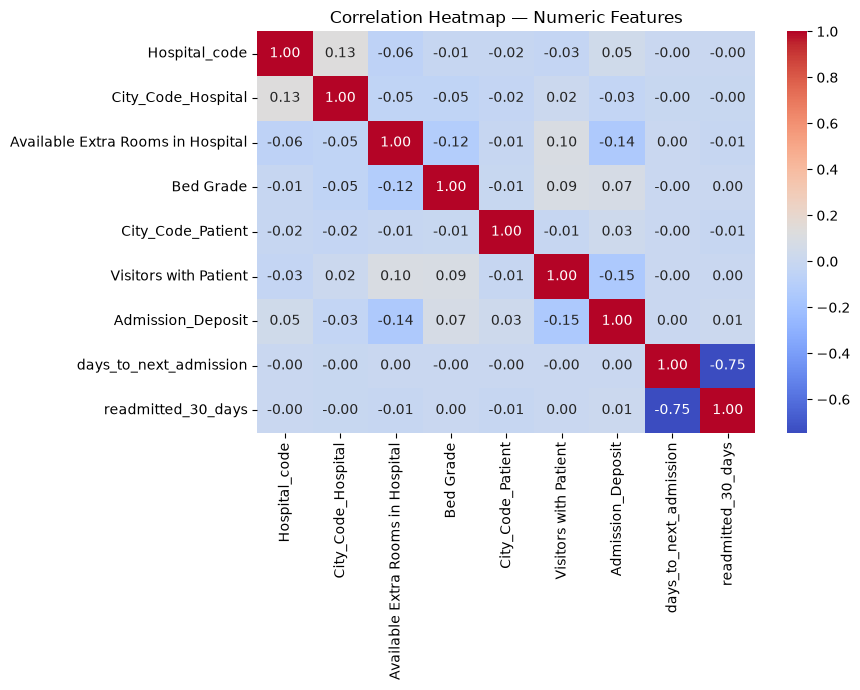

In [7]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["case_id", "patientid"]]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("eda2_correlation_heatmap.png", dpi=100)
plt.show()
